EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


data elo ranking: https://www.kaggle.com/datasets/saifalnimri/international-football-elo-ratings
data resultados historicos https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2017
fixture https://www.kaggle.com/datasets/areezvisram12/fifa-world-cup-2026-match-data-unofficial

In [2]:
df_intl_results = pd.read_csv('../data/raw/results.csv')
df_intl_results['date'] = pd.to_datetime(df_intl_results['date'], format='mixed')

fnames = pd.read_csv('../data/raw/former_names.csv')

matches = pd.read_csv('../data/raw/matches.csv')
df_teams = pd.read_csv('../data/raw/teams.csv')
#wc_raw = pd.read_csv('../data/raw/wc_matches.csv')
#wc_raw.columns = wc_raw.columns.str.strip()

elo = pd.read_csv('../data/raw/eloratings.csv')
elo['date'] = pd.to_datetime(elo['date'], format='mixed')
elo['team'] = elo['team'].str.replace('\xa0', ' ', regex=False)



print(f'International results : {len(df_intl_results):,} rows ({df_intl_results["date"].min().year}-{df_intl_results["date"].max().year})')
#print(f'WC matches            : {len(wc_raw):,} rows')
print(f'ELO ratings           : {len(elo):,} rows')
#print(f'2026 Groups           : {len(groups)} rows')

International results : 49,287 rows (1872-2026)
ELO ratings           : 6,678 rows


In [3]:
df_intl_results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [4]:
df_intl_results.describe()


,date,home_score,away_score
count,49287,49215.000000,49215.000000
mean,1994-04-13 22:21:42.915576064,1.756091,1.182404
min,1872-11-30 00:00:00,0.000000,0.000000
25%,1980-07-27 00:00:00,1.000000,0.000000
50%,2000-06-18 00:00:00,1.000000,1.000000
75%,2013-06-08 00:00:00,2.000000,2.000000
max,2026-06-27 00:00:00,31.000000,21.000000
std,NaN,1.770617,1.401770


In [5]:
df_intl_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49287 non-null  datetime64[ns]
 1   home_team   49287 non-null  object        
 2   away_team   49287 non-null  object        
 3   home_score  49215 non-null  float64       
 4   away_score  49215 non-null  float64       
 5   tournament  49287 non-null  object        
 6   city        49287 non-null  object        
 7   country     49287 non-null  object        
 8   neutral     49287 non-null  bool          
dtypes: bool(1), datetime64[ns](1), float64(2), object(5)
memory usage: 3.1+ MB


For the historical performance of the national teams we will consider the results of former country name to the current country name.

In [6]:
formerdict = fnames.set_index('former')['current'].to_dict()
df_intl_results['home_team'].replace(formerdict)
df_intl_results['away_team'].replace(formerdict)

0           England
1          Scotland
2           England
3          Scotland
4           England
            ...    
49282     Argentina
49283      Portugal
49284    Uzbekistan
49285       England
49286         Ghana
Name: away_team, Length: 49287, dtype: object

In [7]:
print(df_intl_results['tournament'].value_counts().to_string())

tournament
Friendly                                         18252
FIFA World Cup qualification                      8771
UEFA Euro qualification                           2824
African Cup of Nations qualification              2327
FIFA World Cup                                    1036
Copa América                                       869
African Cup of Nations                             845
AFC Asian Cup qualification                        829
UEFA Nations League                                658
CECAFA Cup                                         620
CFU Caribbean Cup qualification                    606
Merdeka Tournament                                 599
British Home Championship                          523
CONCACAF Nations League                            422
AFC Asian Cup                                      421
Gold Cup                                           420
Gulf Cup                                           410
Island Games                                       394

We will consider only FIFA tournamets or by theri asociated confederations

In [8]:
# Lista de torneos oficiales (FIFA, Continentales y Regionales de Confederación)
torneos_oficiales = [
    # Mundiales y Globales
    'FIFA World Cup', 'FIFA World Cup qualification', 'Confederations Cup', 
    'FIFA Series', 'FIFA 75th Anniversary Cup',
    
    # Europa (UEFA)
    'UEFA Euro', 'UEFA Euro qualification', 'UEFA Nations League',
    
    # Sudamérica (CONMEBOL)
    'Copa América', 'Copa América qualification', 'CONMEBOL–UEFA Cup of Champions',
    
    # Norte y Centroamérica (CONCACAF)
    'Gold Cup', 'Gold Cup qualification', 'CONCACAF Nations League', 
    'CONCACAF Nations League qualification', 'CONCACAF Championship', 
    'CONCACAF Championship qualification', 'UNCAF Cup', 'CFU Caribbean Cup', 
    'CFU Caribbean Cup qualification', 'CCCF Championship', 'NAFC Championship', 
    'NAFU Championship',
    
    # África (CAF)
    'African Cup of Nations', 'African Cup of Nations qualification', 
    'CECAFA Cup', 'COSAFA Cup', 'COSAFA Cup qualification', 
    'Amílcar Cabral Cup', 'West African Cup', 'UDEAC Cup', 'UNIFFAC Cup',
    
    # Asia (AFC)
    'AFC Asian Cup', 'AFC Asian Cup qualification', 'AFC Challenge Cup', 
    'AFC Challenge Cup qualification', 'EAFF Championship', 
    'EAFF Championship qualification', 'WAFF Championship', 'SAFF Cup', 
    'AFF Championship', 'AFF Championship qualification', 'ASEAN Championship', 
    'ASEAN Championship qualification', 'CAFA Nations Cup',
    
    # Oceanía (OFC)
    'Oceania Nations Cup', 'Oceania Nations Cup qualification', 'Melanesia Cup'
]

# Filtrar el DataFrame: Solo filas donde el torneo esté en nuestra lista
df_intl_results = df_intl_results[df_intl_results['tournament'].isin(torneos_oficiales)]

print(df_intl_results['tournament'].value_counts().to_string())

tournament
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
UEFA Euro                                 388
COSAFA Cup                                354
AFF Championship                          291
CFU Caribbean Cup                         251
Amílcar Cabral Cup                        235
CONCACAF Championship                     169
UNCAF Cup                                 164
SAFF Cup                                  162
CONCACAF Championship q

In [9]:
# Quitar espacios en blanco al inicio y al final
df_teams['team_name'] = df_teams['team_name'].str.strip()
df_intl_results['home_team'] = df_intl_results['home_team'].str.strip()
df_intl_results['away_team'] = df_intl_results['away_team'].str.strip()

In [10]:
# Convertimos a número y nos aseguramos de que los NaN sean 0
df_intl_results['home_score'] = pd.to_numeric(df_intl_results['home_score'], errors='coerce').fillna(0)
df_intl_results['away_score'] = pd.to_numeric(df_intl_results['away_score'], errors='coerce').fillna(0)

In [11]:
# Convertimos a número y nos aseguramos de que los NaN sean 0
df_intl_results['home_score'] = pd.to_numeric(df_intl_results['home_score'], errors='coerce').fillna(0)
df_intl_results['away_score'] = pd.to_numeric(df_intl_results['away_score'], errors='coerce').fillna(0)

In [12]:
# 1. Definimos las correcciones
name_fixes = {
    'USA': 'United States',
    'Côte d\'Ivoire': 'Ivory Coast',
    'IR Iran': 'Iran',
    'Cabo Verde': 'Cape Verde'
}

# 2. Limpiamos espacios invisibles y aplicamos el reemplazo
df_teams['team_name'] = df_teams['team_name'].str.strip().replace(name_fixes)

# Opcional: Limpiar también los nombres en el historial para asegurar el "match"
df_intl_results['home_team'] = df_intl_results['home_team'].str.strip()
df_intl_results['away_team'] = df_intl_results['away_team'].str.strip()

df_intl_results = df_intl_results.sort_values('date').reset_index(drop=True)

# Brief historical analysis by groups

In [13]:
# 1. Crear un dataframe de "Perspectiva por Equipo"
# Derivamos los datos del equipo local
home = df_intl_results[['home_team', 'home_score', 'away_score']].rename(
    columns={'home_team': 'team', 'home_score': 'goals_for', 'away_score': 'goals_against'}
)

# Derivamos los datos del equipo visitante
away = df_intl_results[['away_team', 'away_score', 'home_score']].rename(
    columns={'away_team': 'team', 'away_score': 'goals_for', 'home_score': 'goals_against'}
)

# 2. Concatenamos ambos para tener una lista única de participaciones
all_performances = pd.concat([home, away])

# 3. Calculamos victorias, derrotas y empates de forma vectorizada
all_performances['win'] = (all_performances['goals_for'] > all_performances['goals_against']).astype(int)
all_performances['loss'] = (all_performances['goals_for'] < all_performances['goals_against']).astype(int)
all_performances['draw'] = (all_performances['goals_for'] == all_performances['goals_against']).astype(int)

# 4. Agrupamos por equipo para tener los totales históricos
team_stats = all_performances.groupby('team').agg({
    'win': 'sum',
    'loss': 'sum',
    'draw': 'sum',
    'goals_for': 'sum',
    'goals_against': 'sum',
    'team': 'count' # Esto nos da el total de partidos
}).rename(columns={'team': 'total_matches'}).reset_index()

# 5. Cruzamos con tu lista de clasificados (df_teams)
# Esto descarta automáticamente a los que no te interesan
df_final_stats = pd.merge(df_teams, team_stats, left_on='team_name', right_on='team', how='inner')

In [14]:
df_final_stats.head()

,id,team_name,fifa_code,group_letter,team,win,loss,draw,goals_for,goals_against,total_matches
0,1,Mexico,MEX,A,Mexico,268,104,101,932.0,430.0,473
1,2,South Africa,RSA,A,South Africa,124,60,91,365.0,239.0,275
2,3,South Korea,KOR,A,South Korea,190,71,96,671.0,306.0,357
3,4,Czech Republic,CZE,A,Czech Republic,122,63,41,391.0,218.0,226
4,5,Canada,CAN,B,Canada,106,74,63,372.0,270.0,243



GROUP A STATISTICS
     team_name  win  loss  draw  goals_for  goals_against
        Mexico  268   104   101      932.0          430.0
  South Africa  124    60    91      365.0          239.0
   South Korea  190    71    96      671.0          306.0
Czech Republic  122    63    41      391.0          218.0


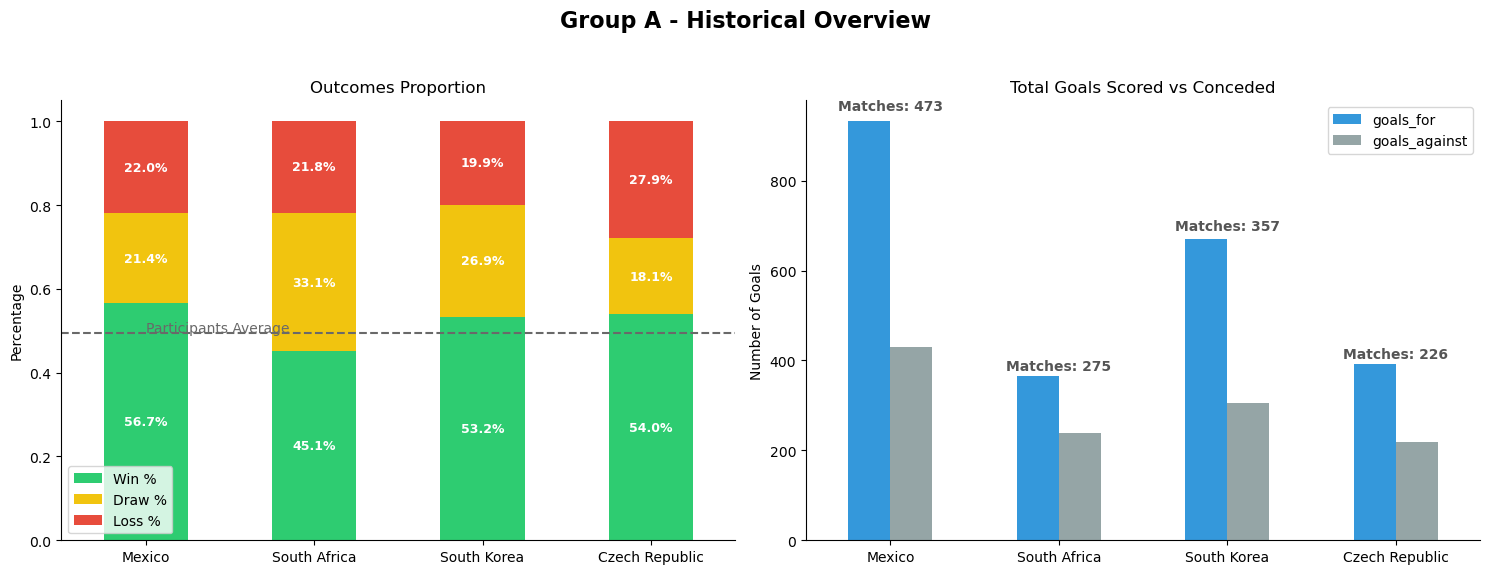


GROUP B STATISTICS
             team_name  win  loss  draw  goals_for  goals_against
                Canada  106    74    63      372.0          270.0
Bosnia and Herzegovina   70    70    40      269.0          247.0
                 Qatar  119    79    49      410.0          268.0
           Switzerland  146   105    96      543.0          425.0


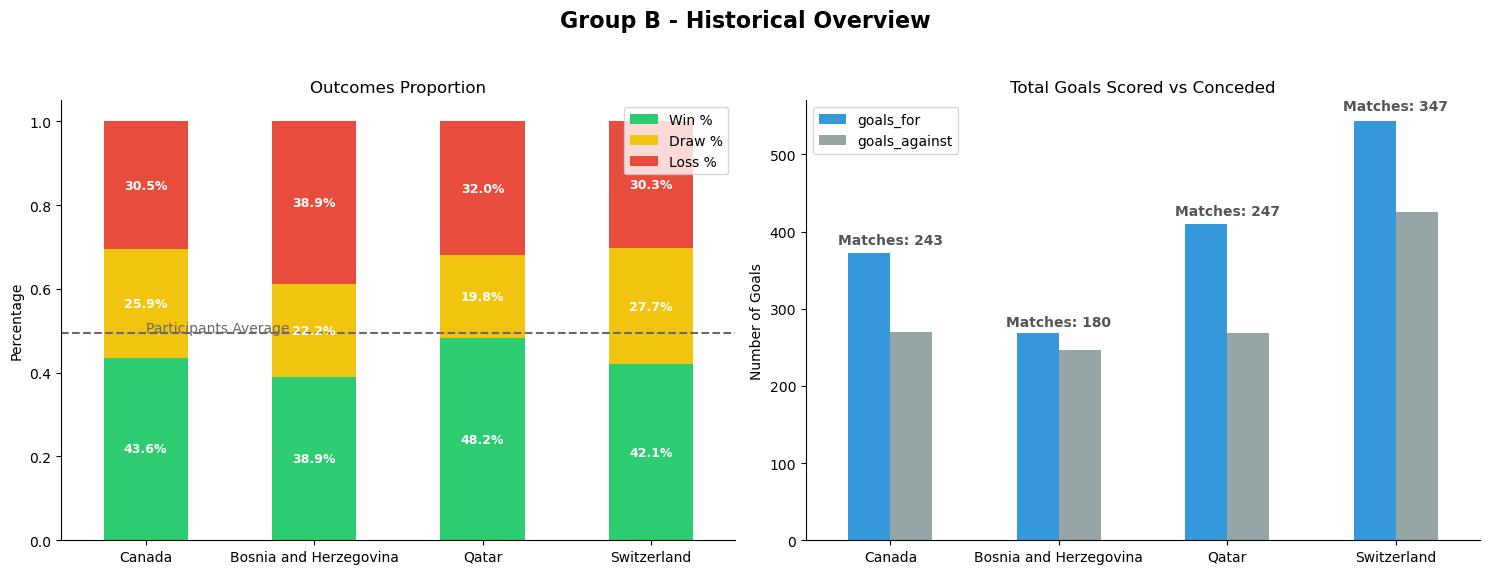


GROUP C STATISTICS
team_name  win  loss  draw  goals_for  goals_against
   Brazil  306    91   107     1075.0          443.0
  Morocco  168    73    97      501.0          242.0
    Haiti  142    94    59      544.0          366.0
 Scotland  150   101    74      471.0          366.0


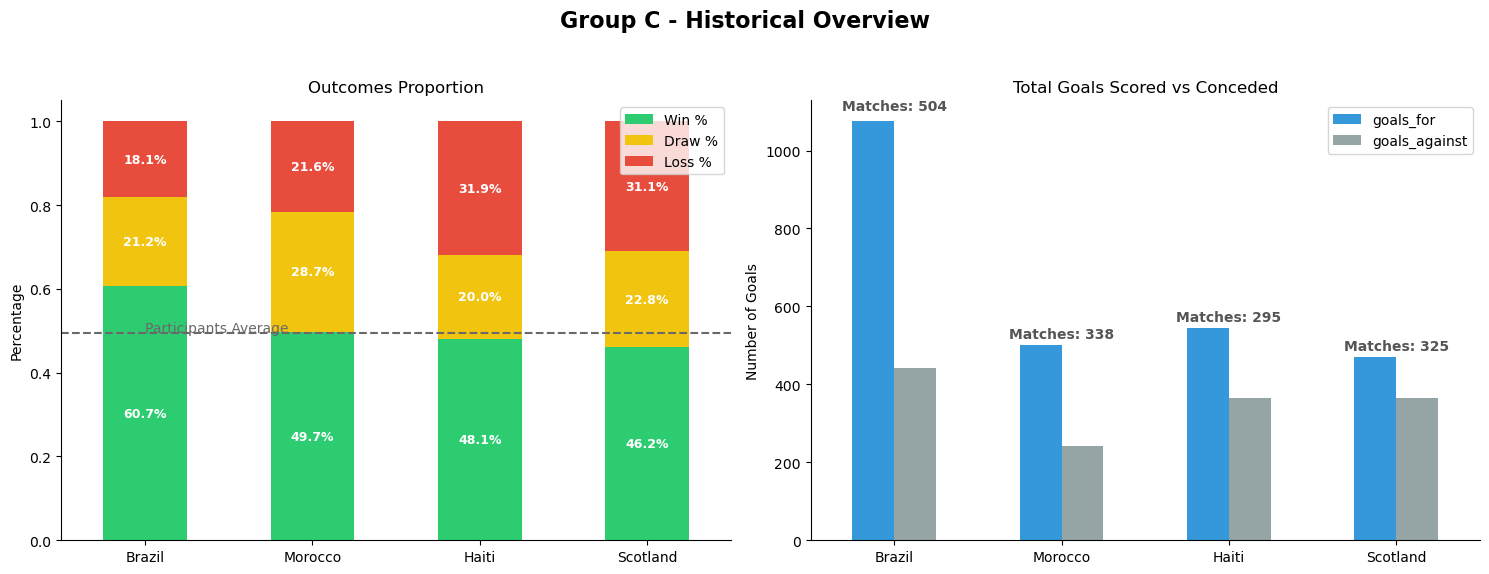


GROUP D STATISTICS
    team_name  win  loss  draw  goals_for  goals_against
United States  194   101    68      629.0          402.0
     Paraguay  148   152   102      529.0          577.0
    Australia  160    59    62      689.0          237.0
       Turkey  140   128    72      482.0          467.0


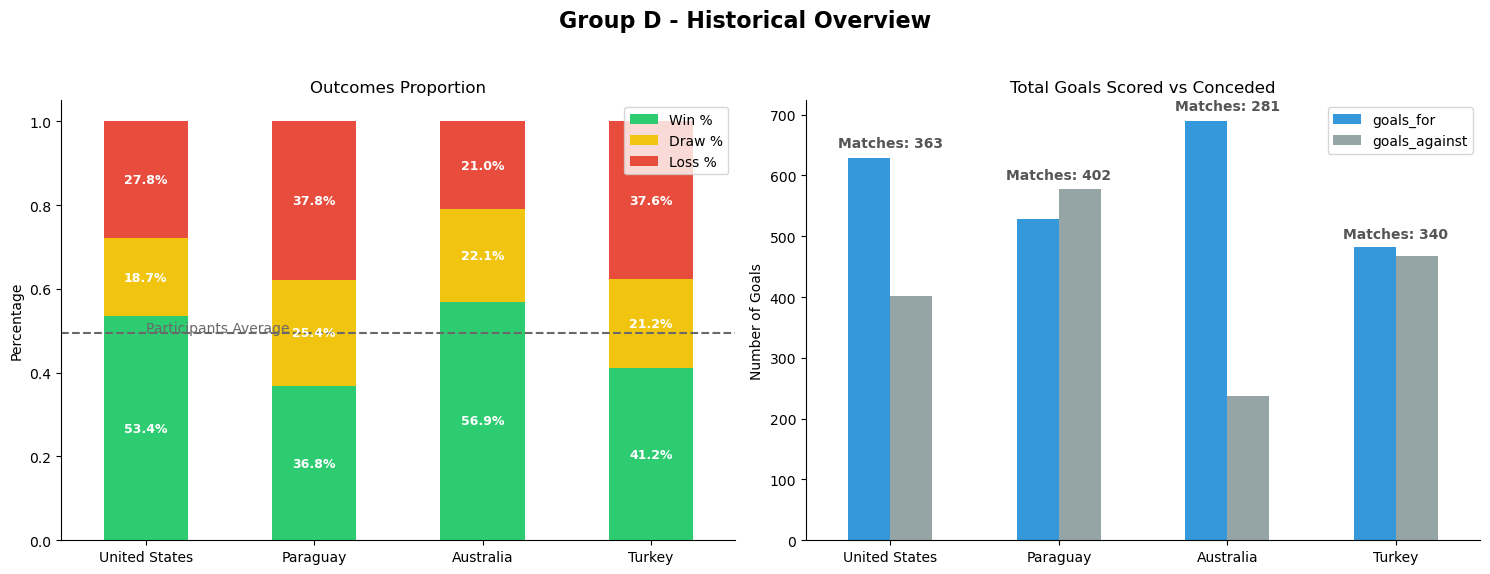


GROUP E STATISTICS
  team_name  win  loss  draw  goals_for  goals_against
    Germany  278    60    90     1009.0          397.0
    Curaçao   74    97    65      350.0          385.0
Ivory Coast  189    73    91      612.0          321.0
    Ecuador   85   164    80      368.0          578.0


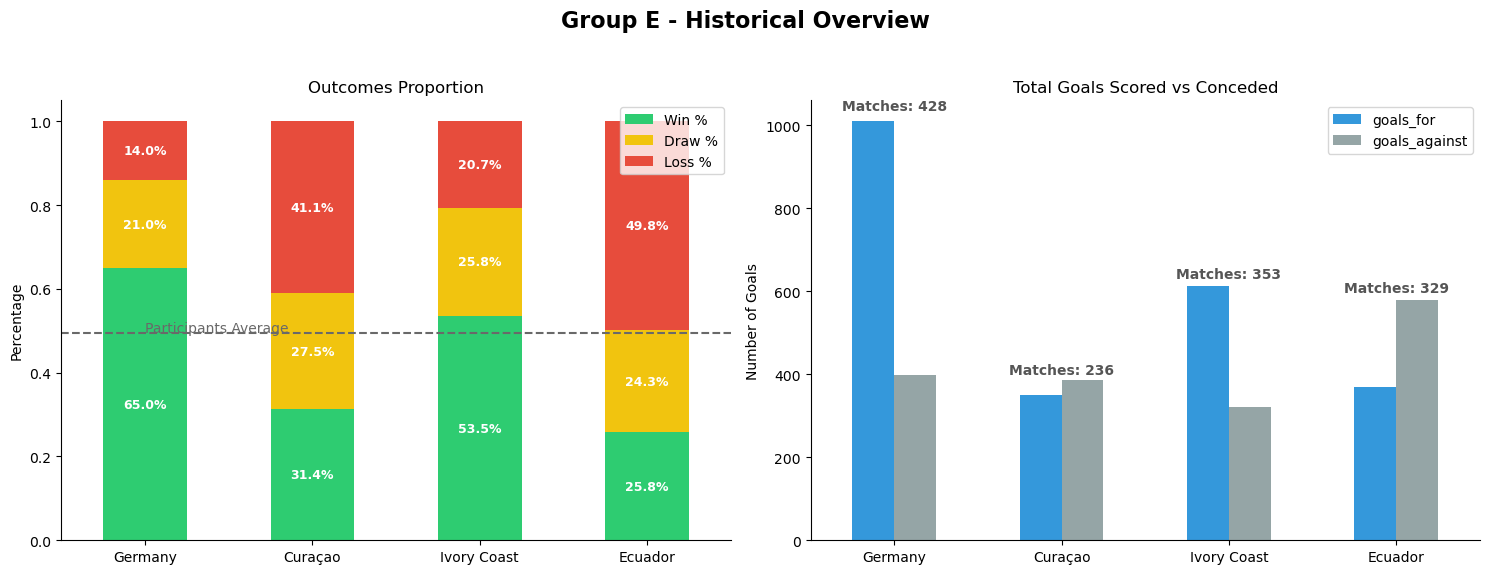


GROUP F STATISTICS
  team_name  win  loss  draw  goals_for  goals_against
Netherlands  245    76    80      880.0          339.0
      Japan  170    71    66      613.0          258.0
     Sweden  187   108    76      647.0          399.0
    Tunisia  157    83    99      503.0          299.0


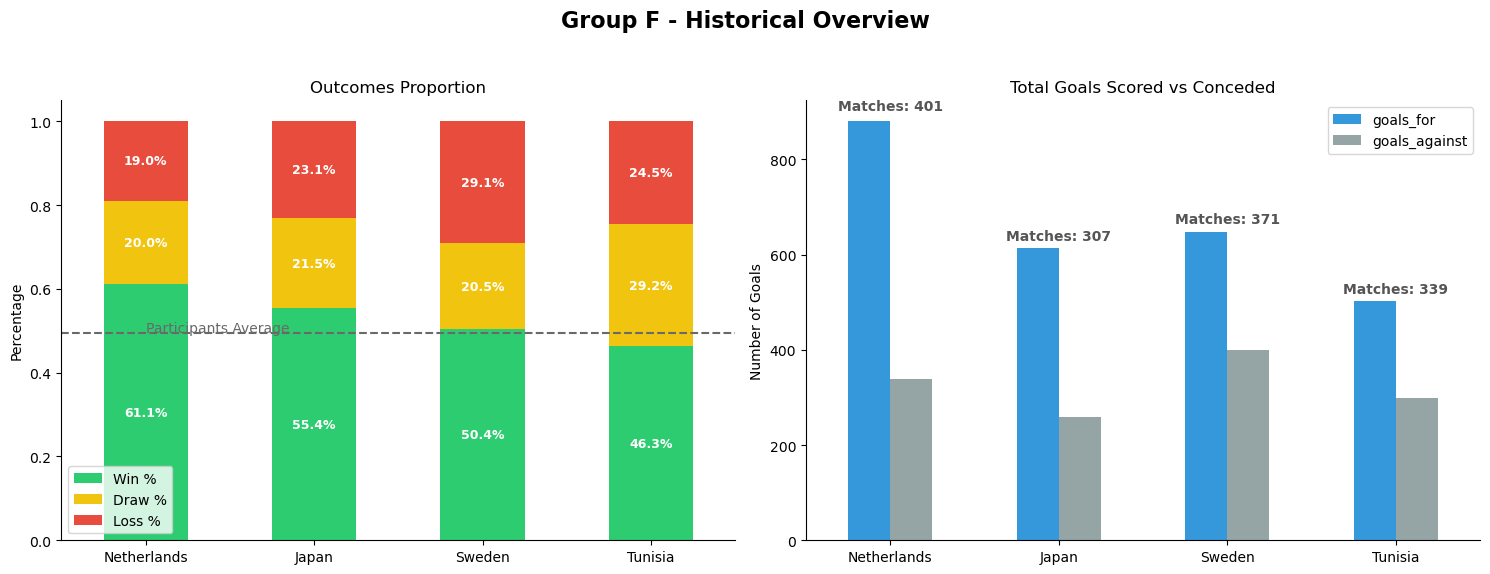


GROUP G STATISTICS
  team_name  win  loss  draw  goals_for  goals_against
    Belgium  199   102    76      714.0          414.0
      Egypt  190    81    84      596.0          312.0
       Iran  208    45    81      710.0          226.0
New Zealand   85    45    26      355.0          170.0


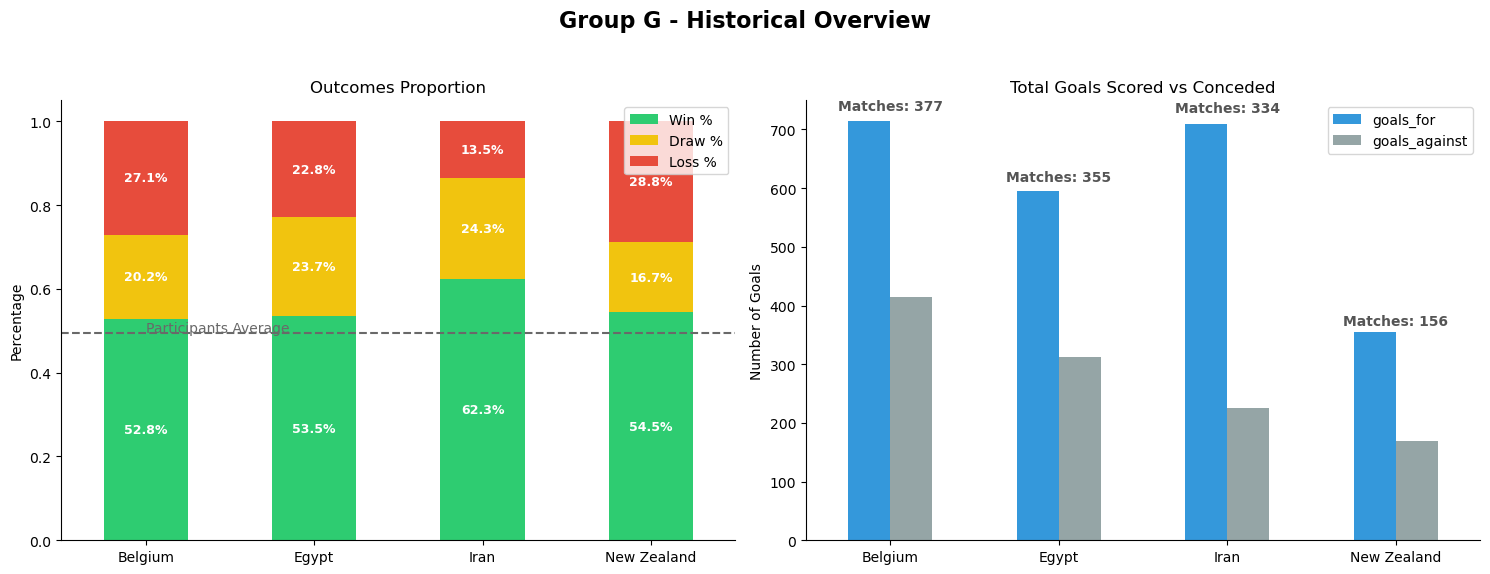


GROUP H STATISTICS
   team_name  win  loss  draw  goals_for  goals_against
       Spain  270    67    90      931.0          342.0
  Cape Verde   70    72    44      194.0          208.0
Saudi Arabia  148    71    65      496.0          268.0
     Uruguay  229   136   110      794.0          515.0


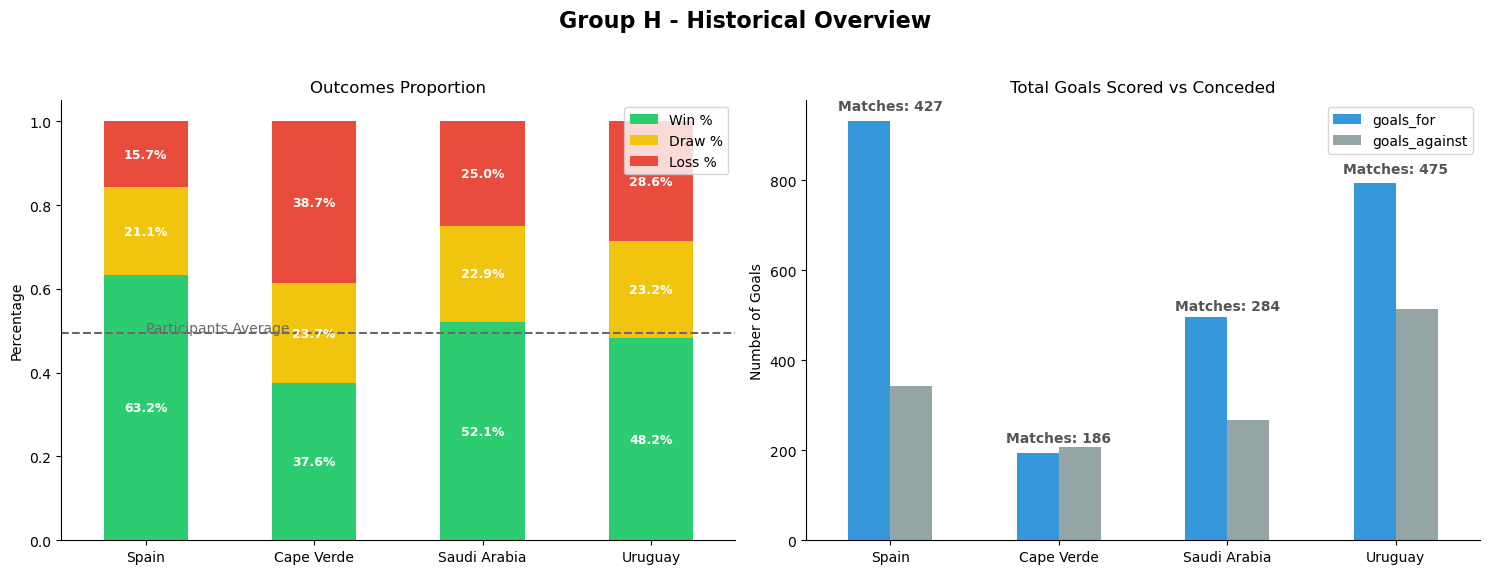


GROUP I STATISTICS
team_name  win  loss  draw  goals_for  goals_against
   France  237    80    92      791.0          364.0
  Senegal  190    82   103      553.0          297.0
     Iraq  126    69    63      424.0          237.0
   Norway  124   120    71      452.0          406.0


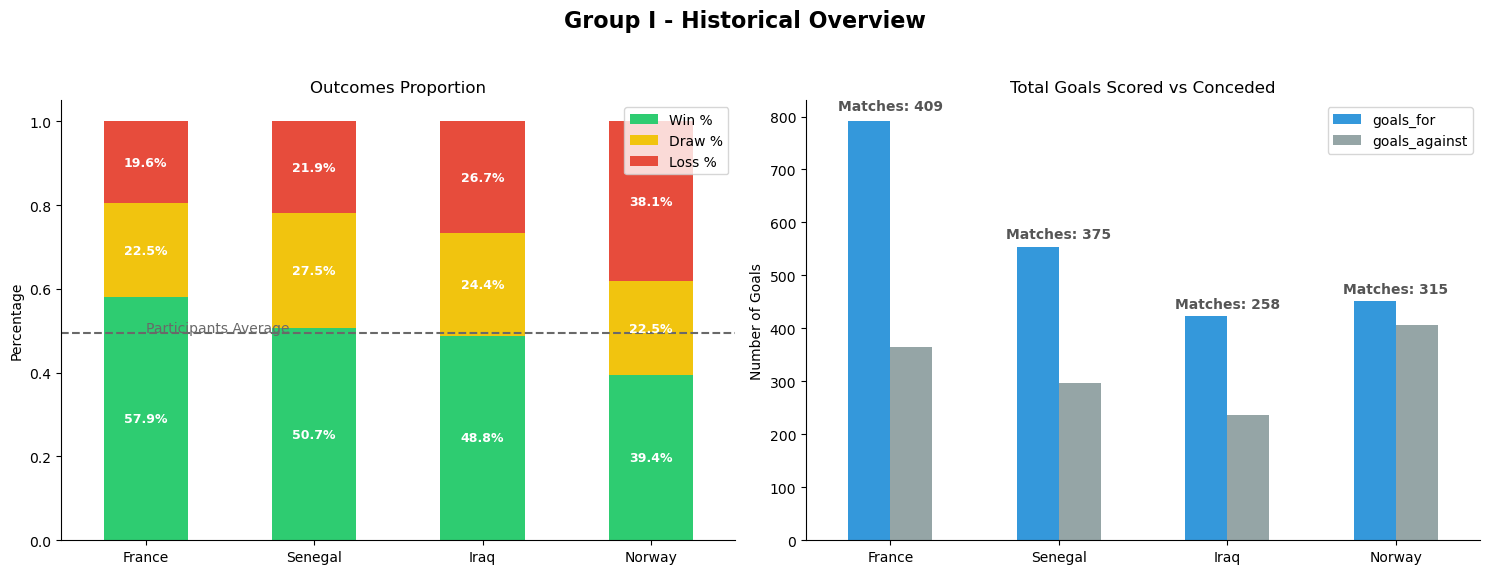


GROUP J STATISTICS
team_name  win  loss  draw  goals_for  goals_against
Argentina  283    88   112      954.0          444.0
  Algeria  161    86    87      534.0          331.0
  Austria  153   113    64      564.0          413.0
   Jordan   86    60    55      300.0          200.0


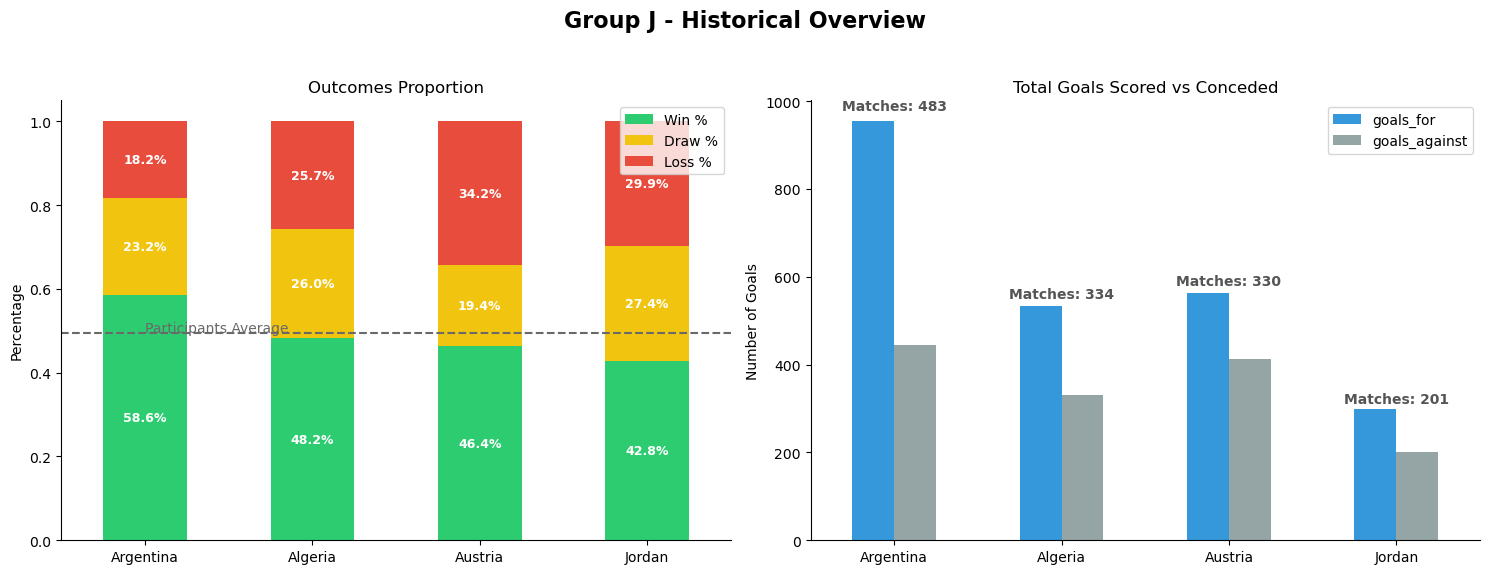


GROUP K STATISTICS
 team_name  win  loss  draw  goals_for  goals_against
  Portugal  221    82    92      741.0          369.0
  DR Congo  136    99    88      469.0          359.0
Uzbekistan  104    47    40      358.0          191.0
  Colombia  136   128    99      435.0          447.0


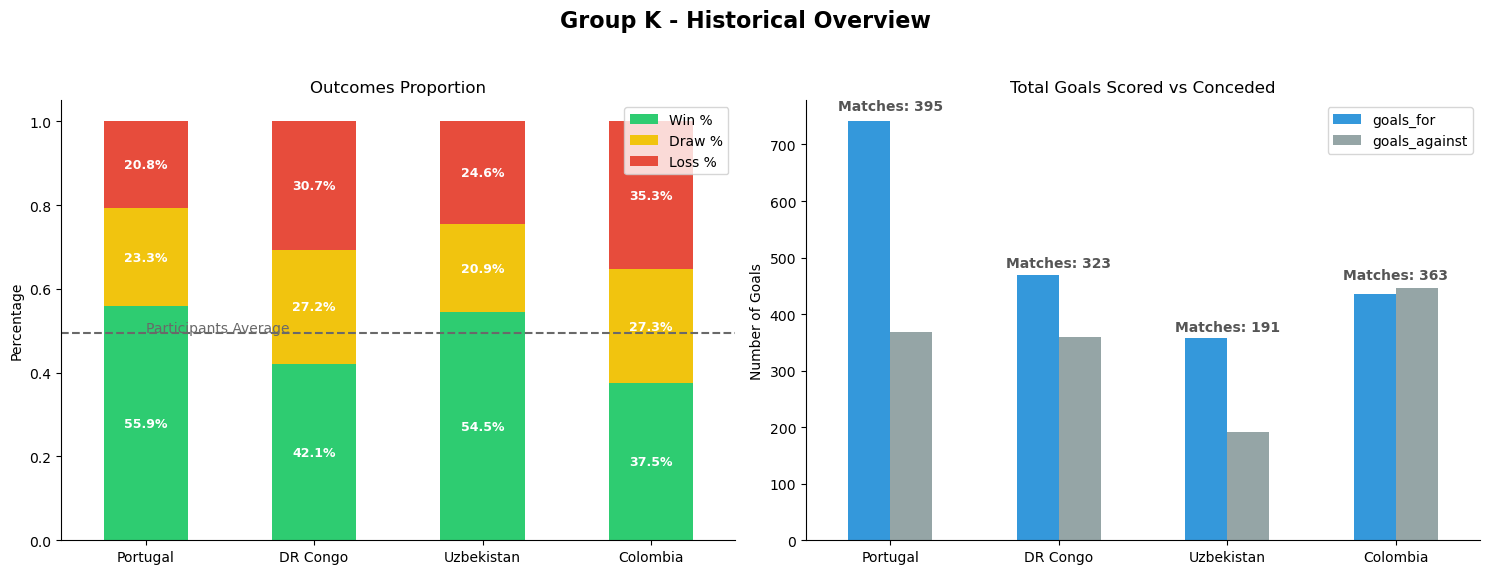


GROUP L STATISTICS
team_name  win  loss  draw  goals_for  goals_against
  England  224    60    99      787.0          265.0
  Croatia  133    48    63      418.0          218.0
    Ghana  176    81    88      527.0          290.0
   Panama  110   117    74      418.0          440.0


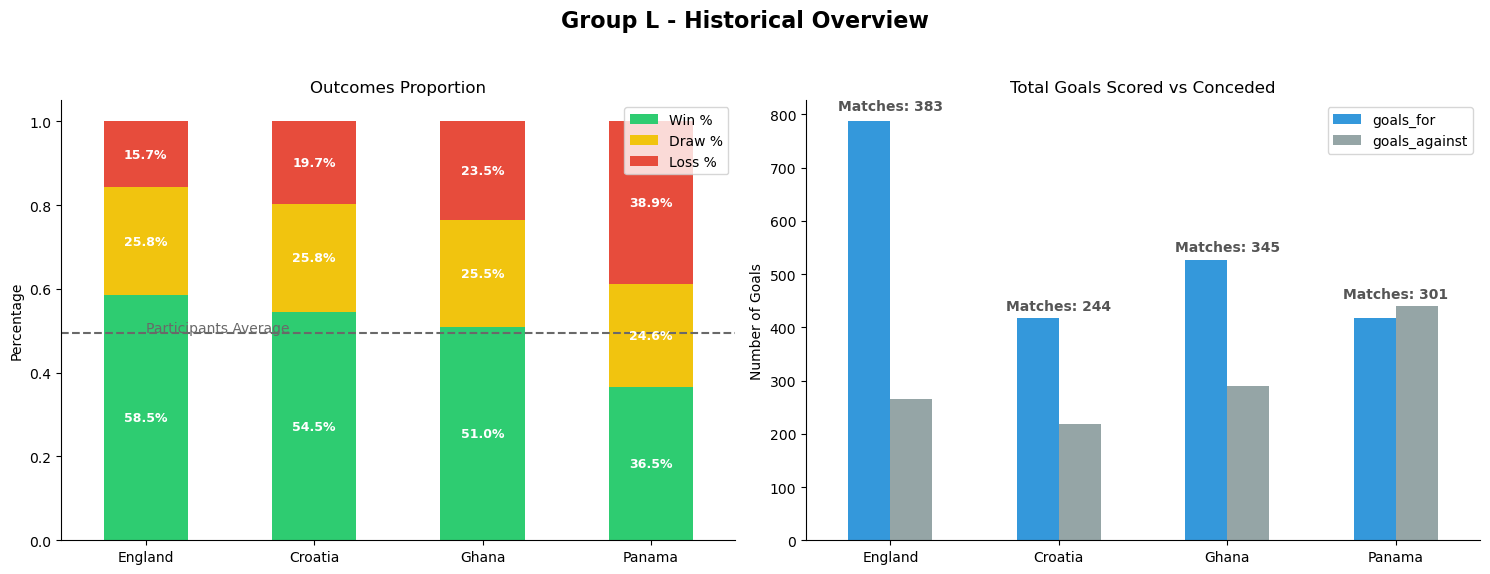

In [15]:
import matplotlib.pyplot as plt

winlevel = (df_final_stats['win'] / df_final_stats['total_matches']).mean()

for g in sorted(df_final_stats['group_letter'].unique()):
    df_g = df_final_stats[df_final_stats['group_letter'] == g].copy()
    
    # Cálculos de proporción
    df_g['Win %'] = df_g['win'] / df_g['total_matches']
    df_g['Loss %'] = df_g['loss'] / df_g['total_matches']
    df_g['Draw %'] = df_g['draw'] / df_g['total_matches']

    # --- TABLA EN CONSOLA ---
    print(f"\n{'='*30}\nGROUP {g} STATISTICS\n{'='*30}")
    print(df_g[['team_name', 'win', 'loss', 'draw', 'goals_for', 'goals_against']].to_string(index=False))

    # --- GRÁFICOS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Group {g} - Historical Overview', fontsize=16, fontweight='bold')

    # --- Gráfico 1: Performance (Stacked Bar) ---
    ax = df_g.set_index('team_name')[['Win %', 'Draw %', 'Loss %']].plot(
        kind='bar', stacked=True, color=['#2ecc71', '#f1c40f', '#e74c3c'], ax=ax1
    )
    ax1.axhline(y=winlevel, color='dimgray', linestyle='--')
    ax1.text(x=0, y=0.49, s="Participants Average", color='dimgray', fontsize=10, va='bottom')

    ax1.set_title('Outcomes Proportion')
    ax1.set_ylabel('Percentage')
    ax1.set_xlabel('')
    
    # Escribir el porcentaje dentro de las barras (solo si es > 0)
    for p in ax1.patches:
        width, height = p.get_width(), p.get_height()
        if height > 0.05: # Solo anotar si el segmento es lo suficientemente grande
            x, y = p.get_xy() 
            ax1.annotate(f'{height:.1%}', (x + width/2, y + height/2), 
                         ha='center', va='center', fontsize=9, color='white', fontweight='bold')

    # --- Gráfico 2: Goals (Scored vs Conceded) ---
    df_g.set_index('team_name')[['goals_for', 'goals_against']].plot(
        kind='bar', color=['#3498db', '#95a5a6'], ax=ax2
    )
    ax2.set_title('Total Goals Scored vs Conceded')
    ax2.set_ylabel('Number of Goals')
    ax2.set_xlabel('')
    
    # Incluir el total de partidos sobre las columnas de goles
    # Iteramos sobre los equipos para poner el texto una sola vez arriba
    for i, matches in enumerate(df_g['total_matches']):
        max_goal = max(df_g.iloc[i]['goals_for'], df_g.iloc[i]['goals_against'])
        ax2.text(i, max_goal + (max_goal * 0.02), f'Matches: {int(matches)}', 
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#555555')

    # --- Limpieza de recuadros (Spines) para ambos gráficos ---
    for ax in [ax1, ax2]:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        # Opcional: rotar nombres de equipos si son largos
        ax.tick_params(axis='x', labelrotation=0)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

guadro dataframe limpios

In [16]:
#df_intl_results.to_csv('../data/processed/matches.csv', index=False)
df_intl_results.to_parquet('../data/processed/matches.parquet')


In [17]:
df_intl_results[df_intl_results['date']<'2018-06-15']

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1916-07-02,Chile,Uruguay,0.0,4.0,Copa América,Buenos Aires,Argentina,True
1,1916-07-06,Argentina,Chile,6.0,1.0,Copa América,Buenos Aires,Argentina,False
2,1916-07-08,Brazil,Chile,1.0,1.0,Copa América,Buenos Aires,Argentina,True
3,1916-07-10,Argentina,Brazil,1.0,1.0,Copa América,Buenos Aires,Argentina,False
4,1916-07-12,Brazil,Uruguay,1.0,2.0,Copa América,Buenos Aires,Argentina,True
...,...,...,...,...,...,...,...,...,...
18944,2018-06-06,Zambia,Madagascar,1.0,0.0,COSAFA Cup,Polokwane,South Africa,True
18945,2018-06-08,South Africa,Botswana,3.0,0.0,COSAFA Cup,Polokwane,South Africa,False
18946,2018-06-08,Madagascar,Lesotho,0.0,1.0,COSAFA Cup,Polokwane,South Africa,True
18947,2018-06-09,Zambia,Zimbabwe,2.0,4.0,COSAFA Cup,Polokwane,South Africa,True


In [20]:
df_intl_results.iloc[:18948]
    

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1916-07-02,Chile,Uruguay,0.0,4.0,Copa América,Buenos Aires,Argentina,True
1,1916-07-06,Argentina,Chile,6.0,1.0,Copa América,Buenos Aires,Argentina,False
2,1916-07-08,Brazil,Chile,1.0,1.0,Copa América,Buenos Aires,Argentina,True
3,1916-07-10,Argentina,Brazil,1.0,1.0,Copa América,Buenos Aires,Argentina,False
4,1916-07-12,Brazil,Uruguay,1.0,2.0,Copa América,Buenos Aires,Argentina,True
...,...,...,...,...,...,...,...,...,...
18943,2018-06-06,Lesotho,Zimbabwe,0.0,0.0,COSAFA Cup,Polokwane,South Africa,True
18944,2018-06-06,Zambia,Madagascar,1.0,0.0,COSAFA Cup,Polokwane,South Africa,True
18945,2018-06-08,South Africa,Botswana,3.0,0.0,COSAFA Cup,Polokwane,South Africa,False
18946,2018-06-08,Madagascar,Lesotho,0.0,1.0,COSAFA Cup,Polokwane,South Africa,True


In [24]:
df_intl_results[df_intl_results['date']<'2022-11-22']

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1916-07-02,Chile,Uruguay,0.0,4.0,Copa América,Buenos Aires,Argentina,True
1,1916-07-06,Argentina,Chile,6.0,1.0,Copa América,Buenos Aires,Argentina,False
2,1916-07-08,Brazil,Chile,1.0,1.0,Copa América,Buenos Aires,Argentina,True
3,1916-07-10,Argentina,Brazil,1.0,1.0,Copa América,Buenos Aires,Argentina,False
4,1916-07-12,Brazil,Uruguay,1.0,2.0,Copa América,Buenos Aires,Argentina,True
...,...,...,...,...,...,...,...,...,...
21728,2022-11-08,Brunei,Timor-Leste,0.0,1.0,AFF Championship qualification,Bandar Seri Begawan,Brunei,False
21729,2022-11-20,Qatar,Ecuador,0.0,2.0,FIFA World Cup,Al Khor,Qatar,False
21730,2022-11-21,United States,Wales,1.0,1.0,FIFA World Cup,Al Rayyan,Qatar,True
21731,2022-11-21,England,Iran,6.0,2.0,FIFA World Cup,Al Rayyan,Qatar,True


In [25]:
df_intl_results.iloc[:21729]

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1916-07-02,Chile,Uruguay,0.0,4.0,Copa América,Buenos Aires,Argentina,True
1,1916-07-06,Argentina,Chile,6.0,1.0,Copa América,Buenos Aires,Argentina,False
2,1916-07-08,Brazil,Chile,1.0,1.0,Copa América,Buenos Aires,Argentina,True
3,1916-07-10,Argentina,Brazil,1.0,1.0,Copa América,Buenos Aires,Argentina,False
4,1916-07-12,Brazil,Uruguay,1.0,2.0,Copa América,Buenos Aires,Argentina,True
...,...,...,...,...,...,...,...,...,...
21724,2022-09-27,Republic of Ireland,Armenia,3.0,2.0,UEFA Nations League,Dublin,Republic of Ireland,False
21725,2022-09-27,Switzerland,Czech Republic,2.0,1.0,UEFA Nations League,St. Gallen,Switzerland,False
21726,2022-09-27,Albania,Iceland,1.0,1.0,UEFA Nations League,Tirana,Albania,False
21727,2022-11-05,Brunei,Timor-Leste,6.0,2.0,AFF Championship qualification,Bandar Seri Begawan,Brunei,False
